In [2]:
# ── IMPORTS ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── LOAD PROCESSED DATA ───────────────────────────────────
X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1155, 216)
X_val shape: (289, 216)
X_test shape: (1459, 216)


In [3]:
# ── APPROACH 1: DROP HIGHLY CORRELATED FEATURES ───────────
# If two features correlate > 0.85 with each other
# they carry almost the same info — keep the one
# that correlates more strongly with target

corr_matrix = X_train.corr().abs()

# get upper triangle only (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85
cols_to_drop = []

for col in upper.columns:
    for idx in upper.index:
        if upper.loc[idx, col] > threshold:
            # keep whichever correlates more with target
            corr_f1 = abs(X_train[idx].corr(y_train))
            corr_f2 = abs(X_train[col].corr(y_train))
            drop = idx if corr_f1 < corr_f2 else col
            cols_to_drop.append(drop)

cols_to_drop = list(set(cols_to_drop))
print(f"Dropping {len(cols_to_drop)} correlated features:")
print(cols_to_drop)

X_train_corr = X_train.drop(columns=cols_to_drop)
X_val_corr = X_val.drop(columns=cols_to_drop)
X_test_corr = X_test.drop(columns=cols_to_drop)

print(f"\nShape after correlation drop: {X_train_corr.shape}")

Dropping 21 correlated features:
['Exterior2nd_MetalSd', 'Exterior2nd_HdBoard', 'CentralAir_N', 'HasBasement', 'Exterior2nd_Wd Sdng', 'MSSubClass_90', 'SaleCondition_Partial', 'YearBuilt', 'HasFireplace', 'Exterior1st_CemntBd', 'MSSubClass_50', 'Exterior1st_VinylSd', 'YearRemodAdd', 'MSSubClass_45', 'MSSubClass_190', 'HasGarage', 'Fireplaces', 'MSSubClass_80', 'RoofStyle_Gable', 'GarageArea', 'GrLivArea']

Shape after correlation drop: (1155, 195)


In [4]:
# ── APPROACH 2: DROP LOW VARIANCE FEATURES ────────────────
# Features where almost every house has the same value
# are useless — they can't help distinguish prices
# e.g. a column that is 0 for 99% of houses tells us nothing

from sklearn.feature_selection import VarianceThreshold

# threshold=0.01 means drop features where variance < 0.01
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

# get which columns to keep
kept_mask = selector.get_support()
kept_cols = X_train.columns[kept_mask].tolist()
dropped_cols = X_train.columns[~kept_mask].tolist()

print(f"Dropped {len(dropped_cols)} low variance features:")
print(dropped_cols)
print(f"\nKept {len(kept_cols)} features")

X_train_var = X_train[kept_cols]
X_val_var = X_val[kept_cols]
X_test_var = X_test[kept_cols]

print(f"Shape after variance drop: {X_train_var.shape}")

Dropped 43 low variance features:
['MSZoning_C (all)', 'LotConfig_FR3', 'Neighborhood_MeadowV', 'Neighborhood_Blmngtn', 'Neighborhood_Veenker', 'Neighborhood_NPkVill', 'Neighborhood_Blueste', 'Condition1_RRNn', 'Condition1_PosA', 'Condition1_RRAe', 'Condition1_RRNe', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Unf', 'HouseStyle_2.5Fin', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_Stone', 'Exterior1st_ImStucc', 'Exterior2nd_Other', 'Exterior2nd_Stone', 'Exterior2nd_AsphShn', 'Exterior2nd_Brk Cmn', 'Exterior2nd_ImStucc', 'Foundation_Stone', 'Foundation_Wood', 'Electrical_FuseP', 'GarageType_CarPort', 'GarageType_2Types', 'SaleType_ConLI', 'SaleType_Oth', 'SaleType_ConLD', 'SaleType_ConLw', 'SaleType_CWD', 'SaleType_Con', 'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'MSSubClass_180', 'MSSubClass_45', 'MSSubClass_40', 'MSSubClass_75']

Kept 173 features
Shape after variance drop: (1155, 173)


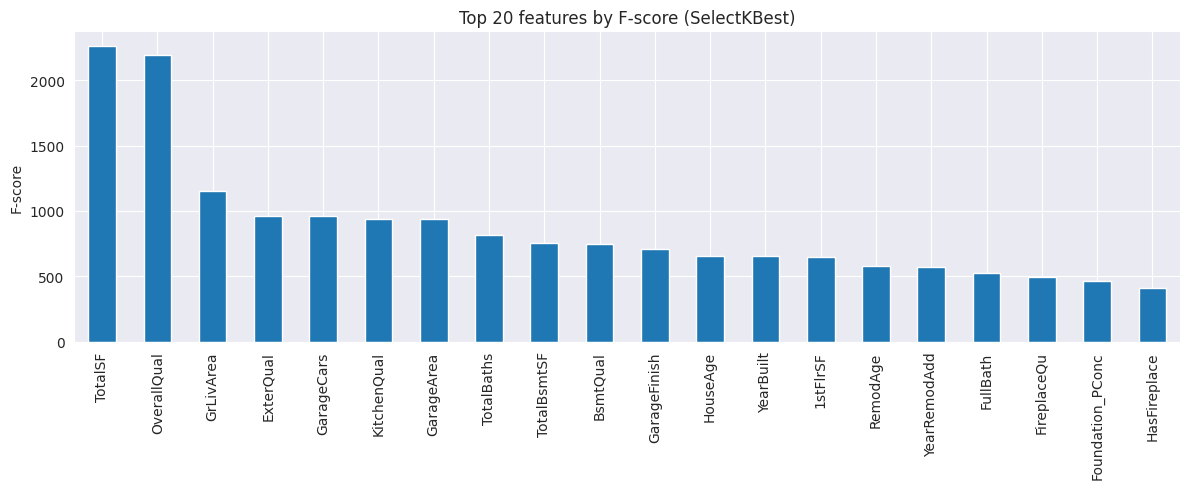

Shape after SelectKBest: (1155, 100)


In [5]:
# ── APPROACH 3: SELECTKBEST ───────────────────────────────
# Statistically scores each feature's relationship with target
# Keeps only the top K most informative features
# Uses f_regression which measures linear correlation strength

from sklearn.feature_selection import SelectKBest, f_regression

K = 100  # keep top 100 features

selector_kbest = SelectKBest(score_func=f_regression, k=K)
selector_kbest.fit(X_train, y_train)

# get selected feature names
kbest_mask = selector_kbest.get_support()
kbest_cols = X_train.columns[kbest_mask].tolist()

# visualize top 20 scores
scores = pd.Series(selector_kbest.scores_, index=X_train.columns)
scores = scores.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
scores.head(20).plot(kind="bar")
plt.title("Top 20 features by F-score (SelectKBest)")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

X_train_kbest = X_train[kbest_cols]
X_val_kbest = X_val[kbest_cols]
X_test_kbest = X_test[kbest_cols]

print(f"Shape after SelectKBest: {X_train_kbest.shape}")

In [6]:
# ── SUMMARY: COMPARE ALL APPROACHES ──────────────────────
print("Feature counts after each approach:")
print(f"  Original:              {X_train.shape[1]} features")
print(f"  Correlation drop:      {X_train_corr.shape[1]} features")
print(f"  Variance drop:         {X_train_var.shape[1]} features")
print(f"  SelectKBest (k=100):   {X_train_kbest.shape[1]} features")

Feature counts after each approach:
  Original:              216 features
  Correlation drop:      195 features
  Variance drop:         173 features
  SelectKBest (k=100):   100 features


In [7]:
# ── SAVE ALL VERSIONS ─────────────────────────────────────
import os
os.makedirs("../data", exist_ok=True)

# version 1: all features (baseline)
X_train.to_csv("../data/X_train_all.csv", index=False)
X_val.to_csv("../data/X_val_all.csv", index=False)
X_test.to_csv("../data/X_test_all.csv", index=False)

# version 2: correlation dropped
X_train_corr.to_csv("../data/X_train_corr.csv", index=False)
X_val_corr.to_csv("../data/X_val_corr.csv", index=False)
X_test_corr.to_csv("../data/X_test_corr.csv", index=False)

# version 3: variance dropped
X_train_var.to_csv("../data/X_train_var.csv", index=False)
X_val_var.to_csv("../data/X_val_var.csv", index=False)
X_test_var.to_csv("../data/X_test_var.csv", index=False)

# version 4: selectkbest
X_train_kbest.to_csv("../data/X_train_kbest.csv", index=False)
X_val_kbest.to_csv("../data/X_val_kbest.csv", index=False)
X_test_kbest.to_csv("../data/X_test_kbest.csv", index=False)

print("Saved all 4 versions!")

Saved all 4 versions!
